<a href="https://colab.research.google.com/github/hiranshree/AIML/blob/main/breakout_heatmap_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.6 MB/s eta 0:00:00
Analyzing 269 buildings on 2 cores...
Success! Processed 95 buildings.


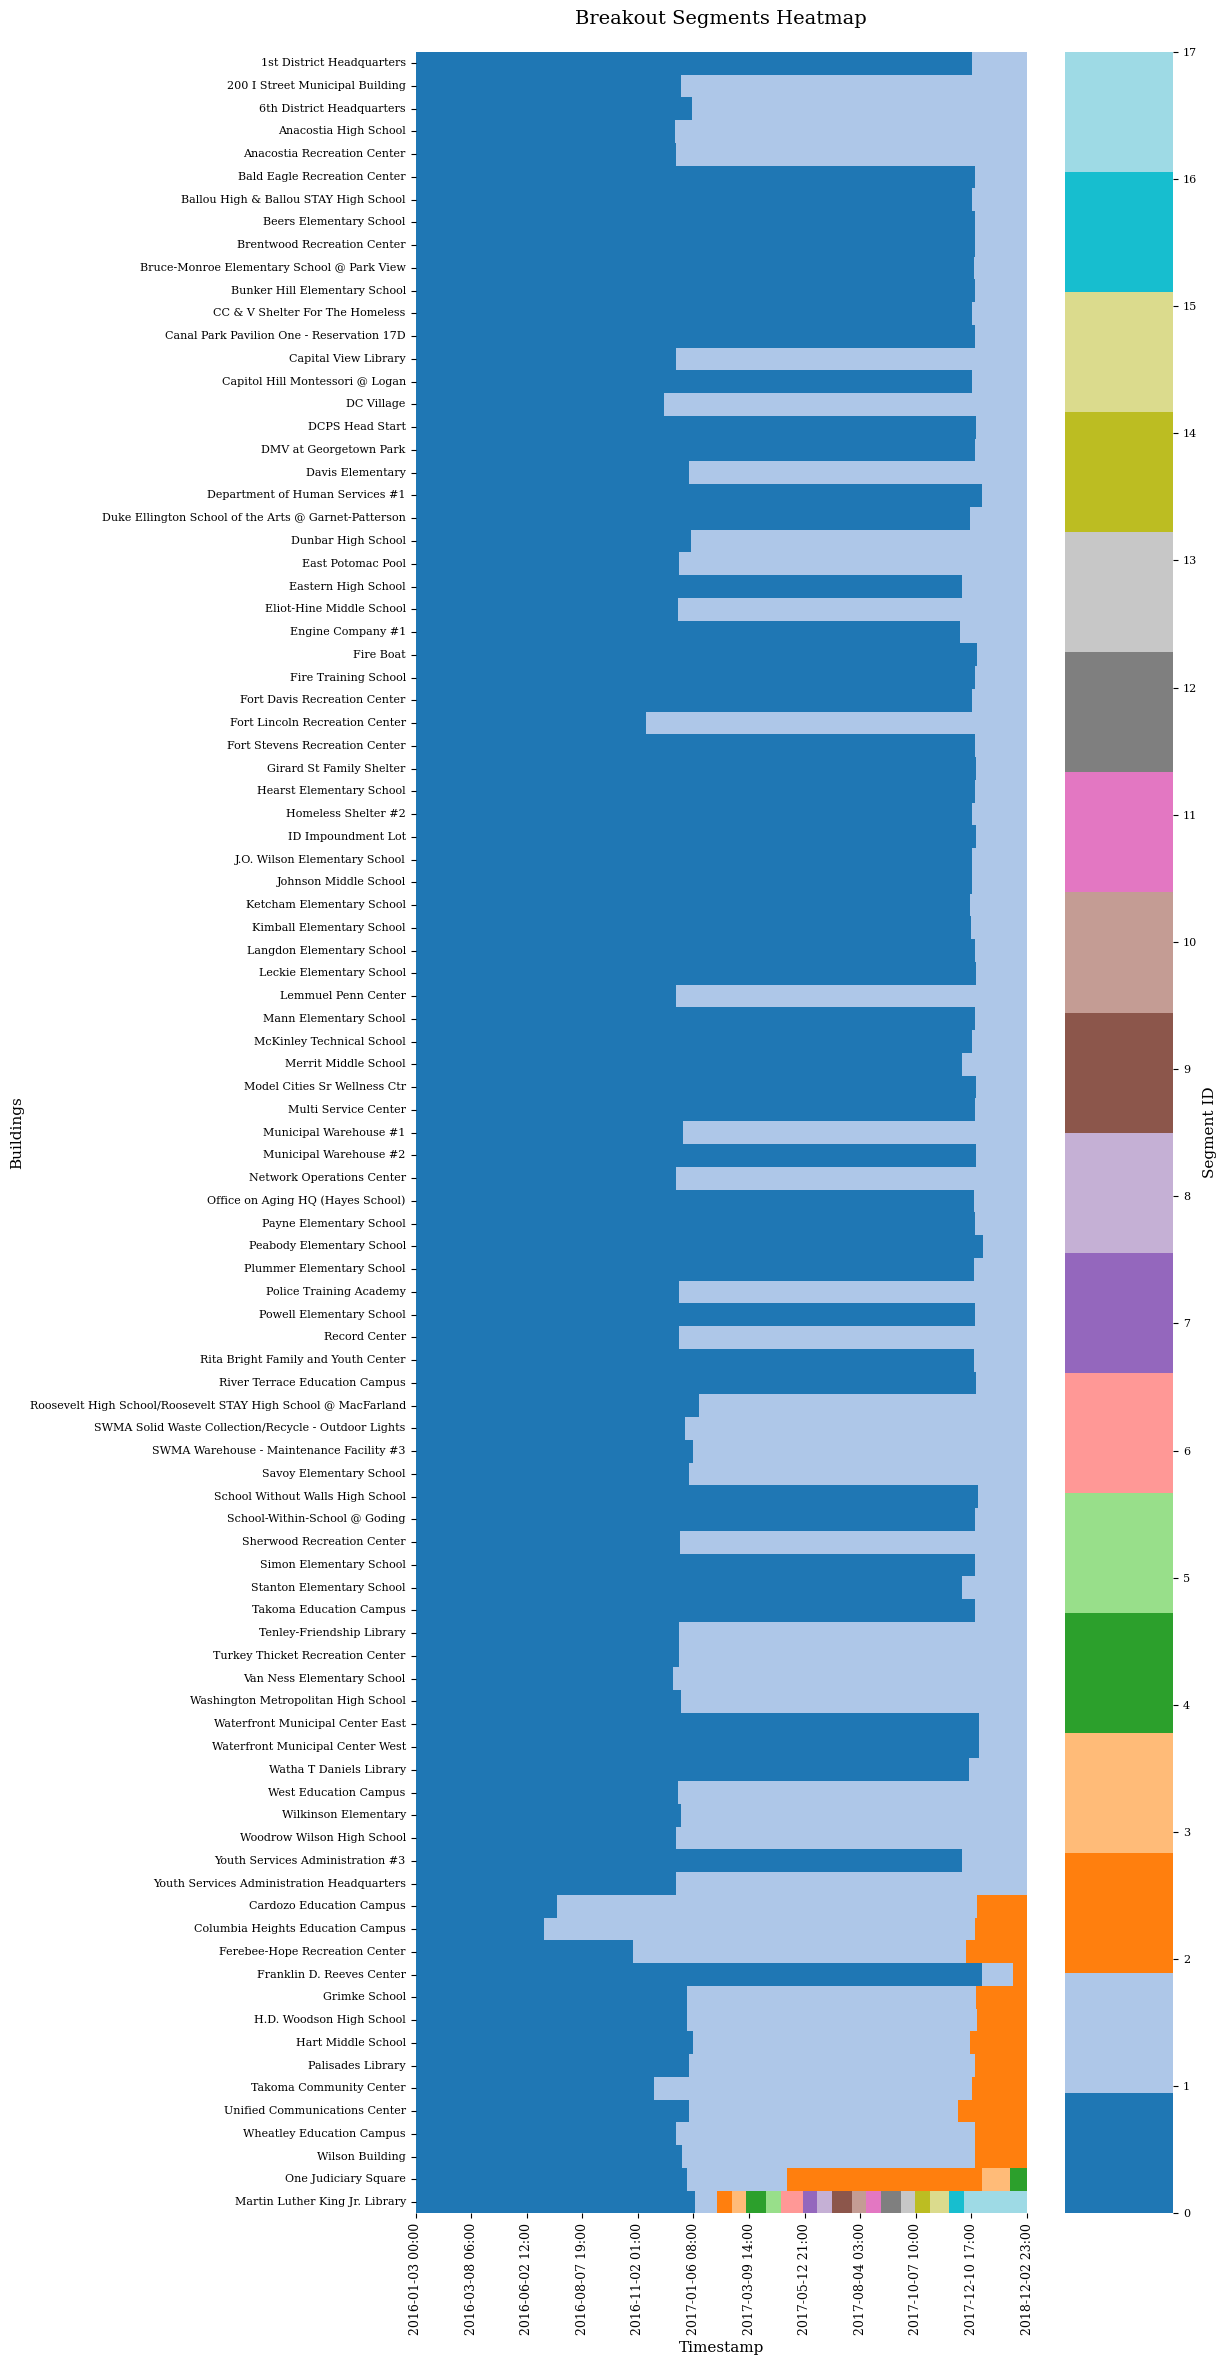

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
!pip install ruptures
import ruptures as rpt
from pathlib import Path
from multiprocessing import Pool, cpu_count

# 1. Faster Detection Logic with Dynamic Penalty
def detect_segments(args):
    """Function to run PELT with a dynamic penalty based on signal variance."""
    col_name, signal, min_size = args

    n = len(signal)
    if n < min_size or np.all(signal == 0):
        return col_name, np.zeros(n, dtype=int)

    try:
        # --- DYNAMIC PENALTY CALCULATION ---
        # Pro Tip: Normalize penalty by standard deviation and log(n)
        # alpha=2 is a good middle ground for energy data
        alpha = 2
        std_dev = np.std(signal)

        # Use a safe penalty: if std_dev is 0, fall back to log(n)
        if std_dev > 0:
            dynamic_pen = alpha * std_dev * np.log(n)
        else:
            dynamic_pen = 2 * np.log(n)

        # PELT analysis
        algo = rpt.Pelt(model="l2", min_size=min_size).fit(signal)
        breakpoints = algo.predict(pen=dynamic_pen)

        # Fast vectorized segment ID assignment
        indices = np.searchsorted(breakpoints, np.arange(n), side='left')
        return col_name, indices
    except:
        return col_name, np.zeros(n, dtype=int)

def plot_breakout_heatmap_optimized(filename, title="Breakout Segments Heatmap"):
    # --- LATEX FONT CONFIGURATION ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 8,
    })

    # 2. Fast Loading
    try:
        if str(filename).endswith('.parquet'):
            df = pd.read_parquet(filename)
        else:
            df = pd.read_csv(filename, index_col=0, parse_dates=True)
        df = df.sort_index()
    except Exception as e:
        print(f"Error loading: {e}")
        return

    # 3. Parallel Execution
    print(f"Analyzing {len(df.columns)} buildings on {cpu_count()} cores...")

    # Pre-clean the whole dataframe for speed
    cleaned_df = df.interpolate(method='linear', limit_direction='both').fillna(0)

    min_size = 168 # 1 week hourly
    # Tasks now only pass col, signal, and min_size (penalty is calculated inside)
    tasks = [(col, cleaned_df[col].values, min_size) for col in df.columns]

    with Pool(processes=cpu_count()) as pool:
        results = pool.map(detect_segments, tasks)

    # Reassemble results
    segment_grid = pd.DataFrame({col: segments for col, segments in results}, index=df.index)

    # 4. Filter & Multi-level Sorting
    segment_counts = segment_grid.apply(lambda x: len(np.unique(x)))
    filtered_cols = segment_counts[segment_counts > 1].index.tolist()

    if not filtered_cols:
        print("No breakouts detected with the current dynamic penalty.")
        return

    # Sort Ascending: Segment count first, then alphabetical
    sorted_cols = sorted(filtered_cols, key=lambda x: (segment_counts[x], x))
    plot_df = segment_grid[sorted_cols].astype(float)

    # 5. Dynamic Visualization
    dynamic_height = max(8, len(plot_df.columns) * 0.25)
    plt.figure(figsize=(12, dynamic_height))

    num_segments = int(plot_df.max().max()) + 1
    cmap = plt.get_cmap('tab20', num_segments)

    ax = sns.heatmap(plot_df.T, cmap=cmap,
                     cbar_kws={'label': 'Segment ID', 'ticks': np.arange(num_segments)})

    plt.title(title, pad=20)
    plt.xlabel("Timestamp")
    plt.ylabel("Buildings")

    xticks = np.linspace(0, len(df) - 1, 12).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(df.index[xticks].strftime('%Y-%m-%d %H:%M'), rotation=90)

    plt.tight_layout()
    plt.savefig('DGS_Breakout_Heatmap.png', dpi=300, bbox_inches='tight')
    print(f"Success! Processed {len(sorted_cols)} buildings.")
    plt.show()

if __name__ == '__main__':
    target_file = '/content/Electricity-hourly.csv'
    plot_breakout_heatmap_optimized(target_file)